In [38]:
path= "../data/raw/ntdoy_4y_data.csv"

In [104]:
import pandas as pd

In [74]:
df = pd.read_csv(path)
df.head(2)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-12-23 00:00:00-05:00,11.947433,12.030388,11.947433,12.030388,1404000,0.0,0.0
1,2021-12-27 00:00:00-05:00,11.850653,12.121243,11.850653,12.107417,2470500,0.0,0.0


In [105]:
import torch
import torch.nn as nn

# FIX 1: Add (nn.Module) here to inherit PyTorch functionality
class LSTMModel(nn.Module): 
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        # FIX 2: super() now works because the class knows its parent is nn.Module
        super(LSTMModel, self).__init__() 
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [106]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def prepare_data(df, window_size=60, split_ratio=0.8):
    data = df['Close'].values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)
    
    X, y = [], []
    for i in range(window_size, len(scaled_data)):
        X.append(scaled_data[i-window_size:i, 0])
        y.append(scaled_data[i, 0])
    
    X, y = np.array(X), np.array(y)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))
    
    # CALCULATE THE SPLIT POINT
    train_size = int(len(X) * split_ratio)
    
    X_train = torch.tensor(X[:train_size], dtype=torch.float32)
    y_train = torch.tensor(y[:train_size], dtype=torch.float32)
    
    X_test = torch.tensor(X[train_size:], dtype=torch.float32)
    y_test = torch.tensor(y[train_size:], dtype=torch.float32)
    
    return X_train, y_train, X_test, y_test, scaler

In [100]:
window = 60
# Usage:
X_train, y_train, X_test, y_test, scaler = prepare_data(df)

model = LSTMModel()
print(list(model.parameters())) # If this is empty or errors, the super() call is missing.
print(model)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 50
for epoch in range(epochs):
    model.train()
    outputs = model(X_train)
    optimizer.zero_grad()
    
    # y_train needs to be reshaped to match output (Batch, 1)
    loss = criterion(outputs, y_train.unsqueeze(1))
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}')

[Parameter containing:
tensor([[-0.0563],
        [-0.0499],
        [-0.1111],
        [ 0.0761],
        [-0.0076],
        [ 0.0295],
        [-0.0004],
        [ 0.0647],
        [ 0.0401],
        [-0.0734],
        [-0.0739],
        [-0.1076],
        [-0.0986],
        [-0.0326],
        [-0.0359],
        [ 0.1219],
        [-0.0871],
        [ 0.1194],
        [ 0.0214],
        [ 0.0758],
        [-0.0206],
        [ 0.0661],
        [-0.0230],
        [-0.0571],
        [-0.0797],
        [ 0.1033],
        [ 0.0994],
        [-0.1049],
        [-0.1210],
        [-0.0208],
        [ 0.0675],
        [-0.1078],
        [-0.0825],
        [-0.0134],
        [ 0.1000],
        [ 0.0405],
        [-0.0628],
        [ 0.0241],
        [-0.1115],
        [-0.0900],
        [-0.0244],
        [ 0.0062],
        [ 0.0291],
        [-0.1217],
        [ 0.0714],
        [ 0.1105],
        [ 0.0750],
        [-0.0641],
        [ 0.0034],
        [ 0.1038],
        [-0.1228],
        

In [101]:
if (epoch+1) % 10 == 0:
        model.eval() # Set to evaluation mode
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test.unsqueeze(1))
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.6f}, Test Loss: {test_loss.item():.6f}')

Epoch [50/50], Train Loss: 0.003517, Test Loss: 0.120533


In [ ]:
pred_rescaled = scaler.inverse_transform(test_outputs.numpy())
true_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))
mape = np.mean(np.abs((true_rescaled - pred_rescaled) / true_rescaled))
print(f"Evaluation Complete. MAPE: {mape:.4%}")

Evaluation Complete. MAPE: 25.8084%


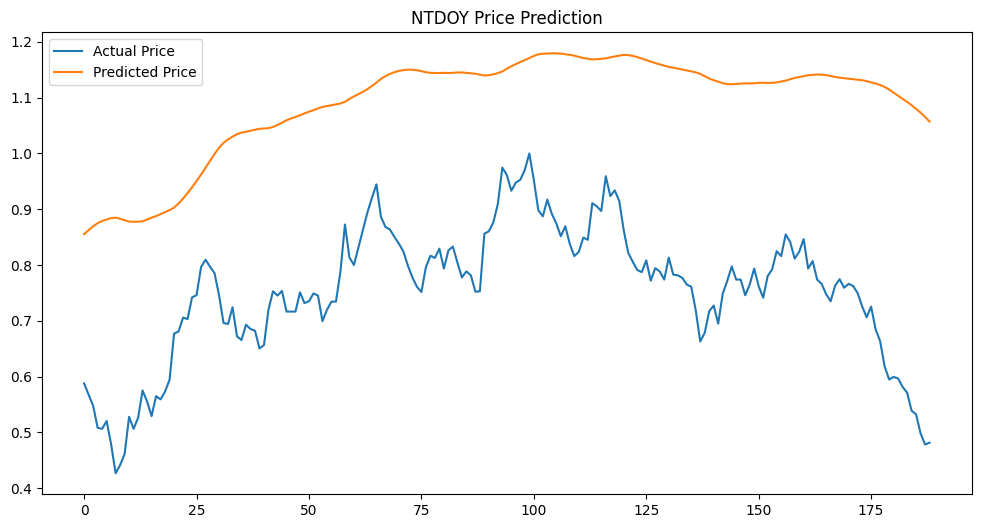

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test, label='Actual Price')
plt.plot(test_outputs, label='Predicted Price')
plt.title('NTDOY Price Prediction')
plt.legend()
plt.show()

In [86]:
rtnr = pd.read_csv('../data/processed/2025-12-28_4f528f46-762d-45c1-a366-a1eef203b4cb.csv')

In [89]:
rtnr.head(10)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-12-23,11.95,12.03,11.95,12.03,1404000,0.0,0.0
1,2021-12-27,11.85,12.12,11.85,12.11,2470500,0.0,0.0
2,2021-12-28,11.79,11.90,11.79,11.81,1528000,0.0,0.0
3,2021-12-29,11.67,11.85,11.67,11.75,798000,0.0,0.0
4,2021-12-30,11.52,11.60,11.48,11.57,1750000,0.0,0.0
5,2021-12-31,11.52,11.58,11.51,11.53,1247000,0.0,0.0
6,2022-01-03,11.65,11.83,11.51,11.55,1986500,0.0,0.0
7,2022-01-04,11.61,11.61,11.40,11.51,1287000,0.0,0.0
8,2022-01-05,11.40,11.41,11.22,11.25,1127500,0.0,0.0
9,2022-01-06,11.19,11.45,11.17,11.35,1696000,0.0,0.0


In [33]:
# Calculate the percentage change including the dividend
df['Total_Return'] = (df['Close'] + df['Dividends']) / df['Open'] - 1

# Look at the days where you actually got a dividend
print(df.loc[df['Dividends'] > 0, ['Date', 'Total_Return']])

                          Date  Total_Return
694  2024-09-30 00:00:00-04:00     -0.004577
818  2025-03-31 00:00:00-04:00      0.015660


In [34]:
result = df.loc[df['Dividends'] != 0, ['Open', 'Close', 'Dividends', 'Stock Splits', 'Total_Return']]

print(result)

          Open      Close  Dividends  Stock Splits  Total_Return
694  13.329873  13.210856      0.058           0.0     -0.004577
818  17.049999  17.170000      0.147           0.0      0.015660


In [36]:
df["Stock Splits"].value_counts()
result = df.loc[df['Stock Splits'] != 0, ['Open', 'Close', 'Dividends', 'Stock Splits', 'Total_Return']]

print(result)

          Open      Close  Dividends  Stock Splits  Total_Return
195  10.300192  10.606334        0.0           5.0      0.029722


In [ ]:
from matplotlib.pyplot import plot, show


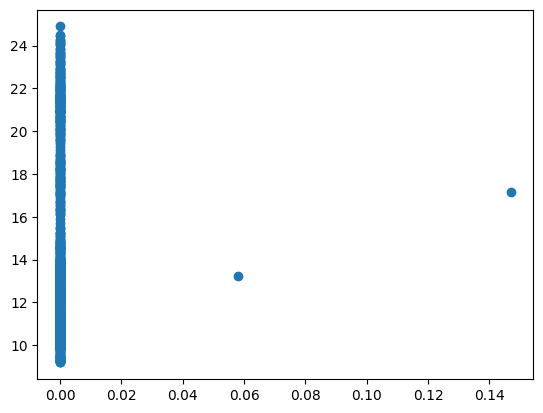

In [29]:
x = df['Close']
y = df['Dividends']
plot(y, x, 'o')
show()

### Training the model using data records from 10 year ago

In [108]:
path= "../data/processed/2026-1-4_51695888-a96a-491a-8bc4-c771279319cf.csv"
df = pd.read_csv(path)
df.head(2)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2016-01-04,3.41,3.41,3.37,3.41,343500,0.0,0.0
1,2016-01-05,3.38,3.38,3.27,3.27,1244000,0.0,0.0


In [ ]:
## Training

window = 60
# Usage:
X_train, y_train, X_test, y_test, scaler = prepare_data(df)

model = LSTMModel()
print(list(model.parameters())) # If this is empty or errors, the super() call is missing.
print(model)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 50
for epoch in range(epochs):
    model.train()
    outputs = model(X_train)
    optimizer.zero_grad()
    
    # y_train needs to be reshaped to match output (Batch, 1)
    loss = criterion(outputs, y_train.unsqueeze(1))
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}')

[Parameter containing:
tensor([[ 0.0979],
        [-0.0188],
        [ 0.0132],
        [ 0.0428],
        [ 0.0364],
        [ 0.0441],
        [ 0.0783],
        [-0.0826],
        [ 0.0985],
        [ 0.0845],
        [-0.0886],
        [-0.0138],
        [-0.0464],
        [ 0.1007],
        [ 0.0716],
        [ 0.0174],
        [-0.0837],
        [-0.0605],
        [ 0.0677],
        [-0.1208],
        [-0.1200],
        [-0.1155],
        [-0.0441],
        [-0.0007],
        [ 0.0539],
        [ 0.0318],
        [ 0.0971],
        [-0.0716],
        [-0.0012],
        [-0.0171],
        [ 0.0600],
        [-0.0546],
        [ 0.1178],
        [-0.1222],
        [-0.0062],
        [-0.0473],
        [ 0.0576],
        [-0.1237],
        [-0.0542],
        [-0.0796],
        [-0.0549],
        [ 0.0242],
        [-0.1215],
        [-0.0034],
        [ 0.0210],
        [ 0.1008],
        [ 0.1061],
        [-0.0954],
        [ 0.0471],
        [-0.0954],
        [ 0.0869],
        

Epoch [50/50], Train Loss: 0.011094, Test Loss: 0.094132
Evaluation Complete. MAPE: 32.9082%


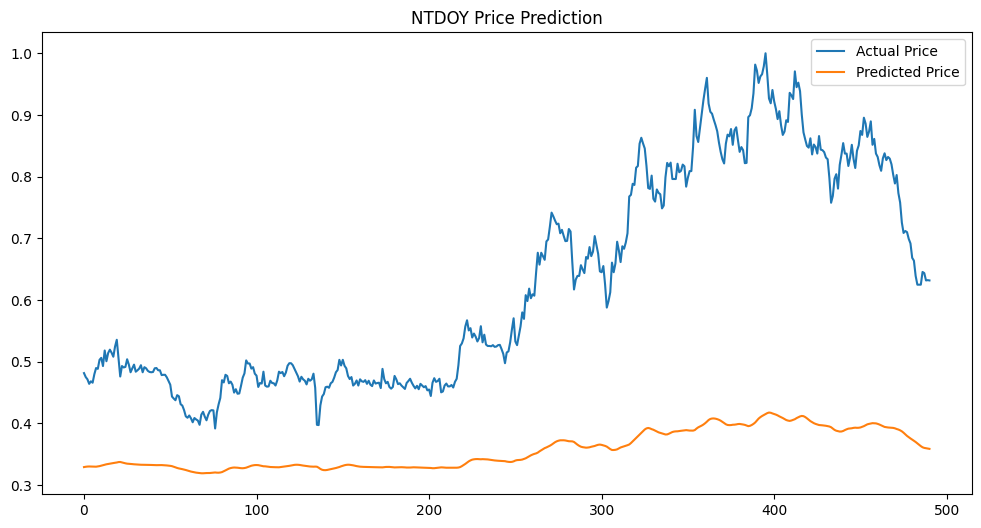

In [110]:
import matplotlib.pyplot as plt

if (epoch+1) % 10 == 0:
        model.eval() # Set to evaluation mode
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test.unsqueeze(1))
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.6f}, Test Loss: {test_loss.item():.6f}')
pred_rescaled = scaler.inverse_transform(test_outputs.numpy())
true_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))
mape = np.mean(np.abs((true_rescaled - pred_rescaled) / true_rescaled))
print(f"Evaluation Complete. MAPE: {mape:.4%}")

plt.figure(figsize=(12,6))
plt.plot(y_test, label='Actual Price')
plt.plot(test_outputs, label='Predicted Price')
plt.title('NTDOY Price Prediction')
plt.legend()
plt.show()

Correlation (First 5 Years): 0.9994
Correlation (Last 5 Years):  0.9991


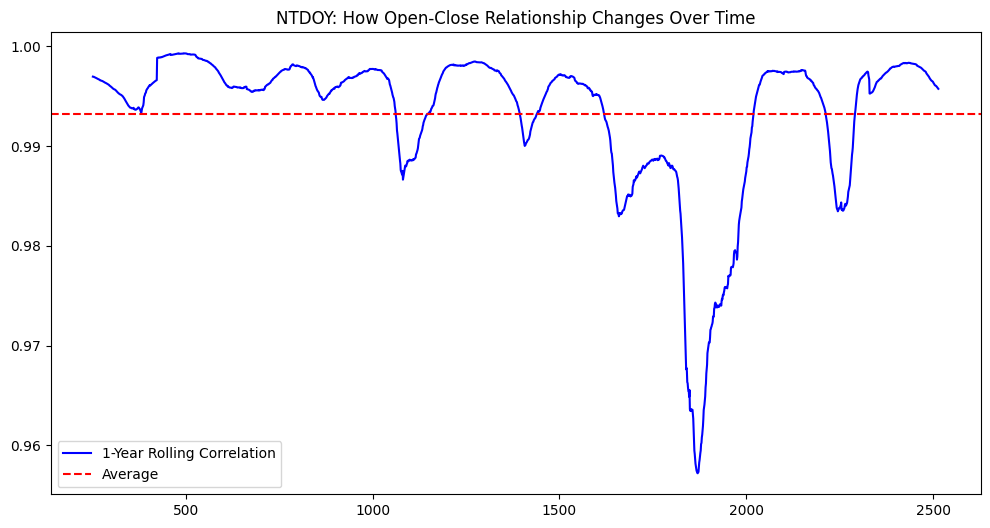

In [111]:
# 1. Split the data into two 5-year periods
mid_point = len(df) // 2
first_half = df.iloc[:mid_point]
second_half = df.iloc[mid_point:]

# 2. Check correlation of 'Open' vs 'Close' for both periods
corr_1 = first_half['Open'].corr(first_half['Close'])
corr_2 = second_half['Open'].corr(second_half['Close'])

print(f"Correlation (First 5 Years): {corr_1:.4f}")
print(f"Correlation (Last 5 Years):  {corr_2:.4f}")

# Calculate the 252-day (1 year) rolling correlation between Open and Close
rolling_corr = df['Open'].rolling(window=252).corr(df['Close'])

plt.figure(figsize=(12, 6))
plt.plot(rolling_corr, label='1-Year Rolling Correlation', color='blue')
plt.axhline(rolling_corr.mean(), color='red', linestyle='--', label='Average')
plt.title('NTDOY: How Open-Close Relationship Changes Over Time')
plt.legend()
plt.show()

### Using all features


In [112]:
import torch
from torch.utils.data import Dataset


class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.seq_len]
        y = self.data[idx + self.seq_len]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


In [ ]:
## Imports
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

## Defining path and reading data
path= "../data/processed/2026-1-4_51695888-a96a-491a-8bc4-c771279319cf.csv"
df = pd.read_csv(path)

## Calculating log returns
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df.dropna(inplace=True)

In [115]:
class LSTMStockPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

In [116]:
SEQ_LEN = 30
TRAIN_SPLIT = 0.8

values = df[['log_return']].values

split_idx = int(len(values) * TRAIN_SPLIT)

train_values = values[:split_idx]
test_values = values[split_idx:]

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_values)
test_scaled = scaler.transform(test_values)


In [117]:
from torch.utils.data import DataLoader

train_dataset = TimeSeriesDataset(train_scaled, SEQ_LEN)
test_dataset = TimeSeriesDataset(test_scaled, SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [118]:
import torch.optim as optim

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = LSTMStockPredictor().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 50

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        preds = model(X)
        loss = criterion(preds.squeeze(), y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        model.eval()
        test_loss = 0

        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                preds = model(X)
                loss = criterion(preds.squeeze(), y)
                test_loss += loss.item()

        print(
            f"Epoch [{epoch+1}/{EPOCHS}] "
            f"Train Loss: {train_loss/len(train_loader):.6f} "
            f"Test Loss: {test_loss/len(test_loader):.6f}"
        )


c:\Users\Overthrive\Documents\faculdade_ml\tech_challenge\MLE-Posgraduate-projects\tech_challenge4\venv\lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Overthrive\Documents\faculdade_ml\tech_challenge\MLE-Posgraduate-projects\tech_challenge4\venv\lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([29, 1])) that is different to the input size (torch.Size([29])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Overthrive\Documents\faculdade_ml\tech_challenge\MLE-Posgraduate-projects\tech_challenge4\venv\lib\site-packages\torch\nn\modules\loss.py

Epoch [10/50] Train Loss: 0.966254 Test Loss: 0.820019
Epoch [20/50] Train Loss: 0.963656 Test Loss: 0.819421
Epoch [30/50] Train Loss: 0.963268 Test Loss: 0.818683
Epoch [40/50] Train Loss: 0.962963 Test Loss: 0.818227
Epoch [50/50] Train Loss: 0.962690 Test Loss: 0.818038


In [119]:
model.eval()

preds = []
trues = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        out = model(X).cpu().numpy()
        preds.extend(out)
        trues.extend(y.numpy())

preds = scaler.inverse_transform(np.array(preds))
trues = scaler.inverse_transform(np.array(trues).reshape(-1, 1))


In [120]:
rmse = np.sqrt(np.mean((trues - preds) ** 2))
mae = np.mean(np.abs(trues - preds))

print(f"RMSE (log-return): {rmse:.6f}")
print(f"MAE  (log-return): {mae:.6f}")


RMSE (log-return): 0.020786
MAE  (log-return): 0.015567


In [121]:
baseline_preds = np.zeros_like(trues)
baseline_rmse = np.sqrt(np.mean((trues - baseline_preds) ** 2))
print(f'baseline RMSE (log-return) using zeros_like metric: {baseline_rmse:.6f}')
      
baseline_preds = np.mean(trues)
baseline_rmse = np.sqrt(np.mean((trues - baseline_preds) ** 2))

print(f'baseline RMSE (log-return) using mean metric: {baseline_rmse:.6f}')

baseline RMSE (log-return) using zeros_like metric: 0.020679
baseline RMSE (log-return) using mean metric: 0.020676


In [122]:
direction_accuracy = np.mean(
    np.sign(trues) == np.sign(preds)
)
print(f"Direction Accuracy: {direction_accuracy:.2%}")


Direction Accuracy: 50.53%


### Using all the features

In [123]:
import numpy as np

df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))

df['hl_range'] = (df['High'] - df['Low']) / df['Close']
df['oc_return'] = np.log(df['Close'] / df['Open'])
df['vol_log'] = np.log(df['Volume'])

df['ret_mean_5'] = df['log_return'].rolling(5).mean()
df['ret_std_5'] = df['log_return'].rolling(5).std()
df['ret_std_10'] = df['log_return'].rolling(10).std()

df.dropna(inplace=True)

In [124]:
features = [
    'Open',
    'High',
    'Low',
    'Close',
    'vol_log',
    'hl_range',
    'oc_return',
    'ret_mean_5',
    'ret_std_5',
    'ret_std_10'
]

X = df[features].values
y = df['log_return'].values

In [125]:
from sklearn.preprocessing import StandardScaler

SEQ_LEN = 30
TRAIN_SPLIT = 0.8

split_idx = int(len(X) * TRAIN_SPLIT)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = y_scaler.transform(y_test.reshape(-1, 1)).flatten()


In [126]:
import torch
from torch.utils.data import Dataset


class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X = X
        self.y = y
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len

    def __getitem__(self, idx):
        X_seq = self.X[idx:idx + self.seq_len]
        y_target = self.y[idx + self.seq_len]
        return (
            torch.tensor(X_seq, dtype=torch.float32),
            torch.tensor(y_target, dtype=torch.float32)
        )

from torch.utils.data import DataLoader

train_ds = TimeSeriesDataset(X_train, y_train, SEQ_LEN)
test_ds = TimeSeriesDataset(X_test, y_test, SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)


In [150]:
import torch.nn as nn


class LSTMStockPredictor(nn.Module):
    def __init__(self, input_size, hidden_size=32):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            dropout=0.3,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)


In [130]:
model = LSTMStockPredictor(input_size=len(features))


In [151]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMStockPredictor(input_size=len(features), hidden_size=16).to(device)
model.to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

c:\Users\Overthrive\Documents\faculdade_ml\tech_challenge\MLE-Posgraduate-projects\tech_challenge4\venv\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


In [ ]:
EPOCHS = 80
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        preds = model(x_batch).squeeze()
        loss = criterion(preds, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{EPOCHS}], "
            f"Train Loss: {epoch_loss / len(train_loader):.6f}"
        )


Epoch [10/50], Train Loss: 0.948723
Epoch [20/50], Train Loss: 0.912270
Epoch [30/50], Train Loss: 0.859100
Epoch [40/50], Train Loss: 0.819407
Epoch [50/50], Train Loss: 0.793554


In [141]:
for x_batch, y_batch in train_loader:
    print("X shape:", x_batch.shape)
    print("y shape:", y_batch.shape)
    print("y mean:", y_batch.mean().item())
    print("y std :", y_batch.std().item())
    break


X shape: torch.Size([32, 30, 10])
y shape: torch.Size([32])
y mean: 0.10087540745735168
y std : 0.9764471650123596


In [142]:
import numpy as np
print("y_train variance:", np.var(y_train))


y_train variance: 0.9999999999999998


In [156]:
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        y = y.to(device)

        preds = model(X).squeeze()

        all_preds.append(preds.cpu())
        all_true.append(y.cpu())

all_preds = torch.cat(all_preds)
all_true  = torch.cat(all_true)

direction_acc = (torch.sign(all_preds) == torch.sign(all_true)).float().mean()

print(f"Directional Accuracy: {direction_acc.item()*100:.2f}%")


Directional Accuracy: 56.05%


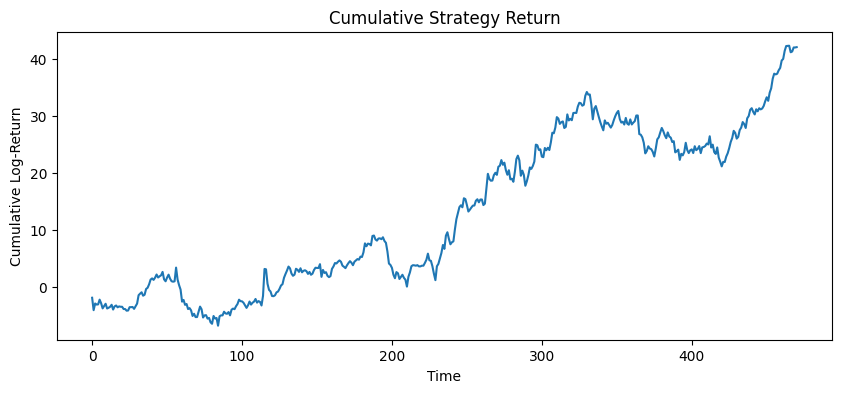

In [158]:
strategy_returns = torch.sign(all_preds) * all_true

cum_return = strategy_returns.cumsum(dim=0)

plt.figure(figsize=(10,4))
plt.plot(cum_return.numpy())
plt.title("Cumulative Strategy Return")
plt.xlabel("Time")
plt.ylabel("Cumulative Log-Return")
plt.show()


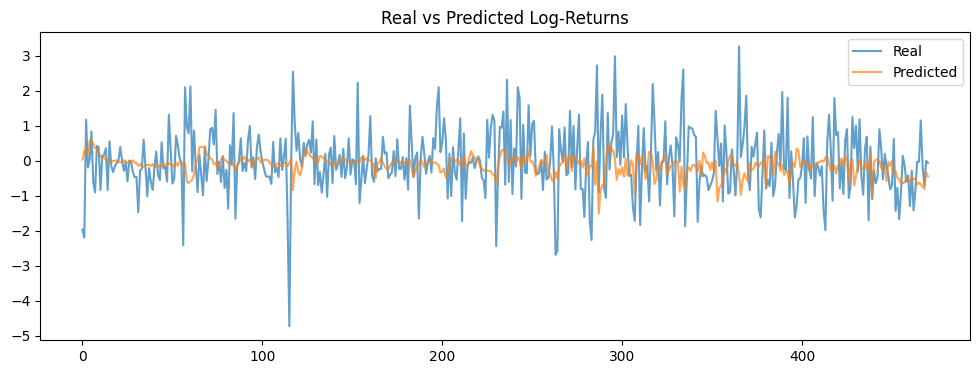

In [160]:
plt.figure(figsize=(12,4))
plt.plot(all_true.numpy(), label="Real", alpha=0.7)
plt.plot(all_preds.numpy(), label="Predicted", alpha=0.7)
plt.legend()
plt.title("Real vs Predicted Log-Returns")
plt.show()